In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import plotly.io as pio
pio.renderers.default = 'notebook'

In [24]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [2]:
df = pd.read_csv('heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [3]:
df.info()
#Feature Description

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.isna().sum()
#Data is Clean No Null Values

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
df.describe().T
#Check statistics of the features

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>],
       [<Axes: title={'center': 'trestbps'}>,
        <Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>],
       [<Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>,
        <Axes: title={'center': 'exang'}>],
       [<Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >]], dtype=object)

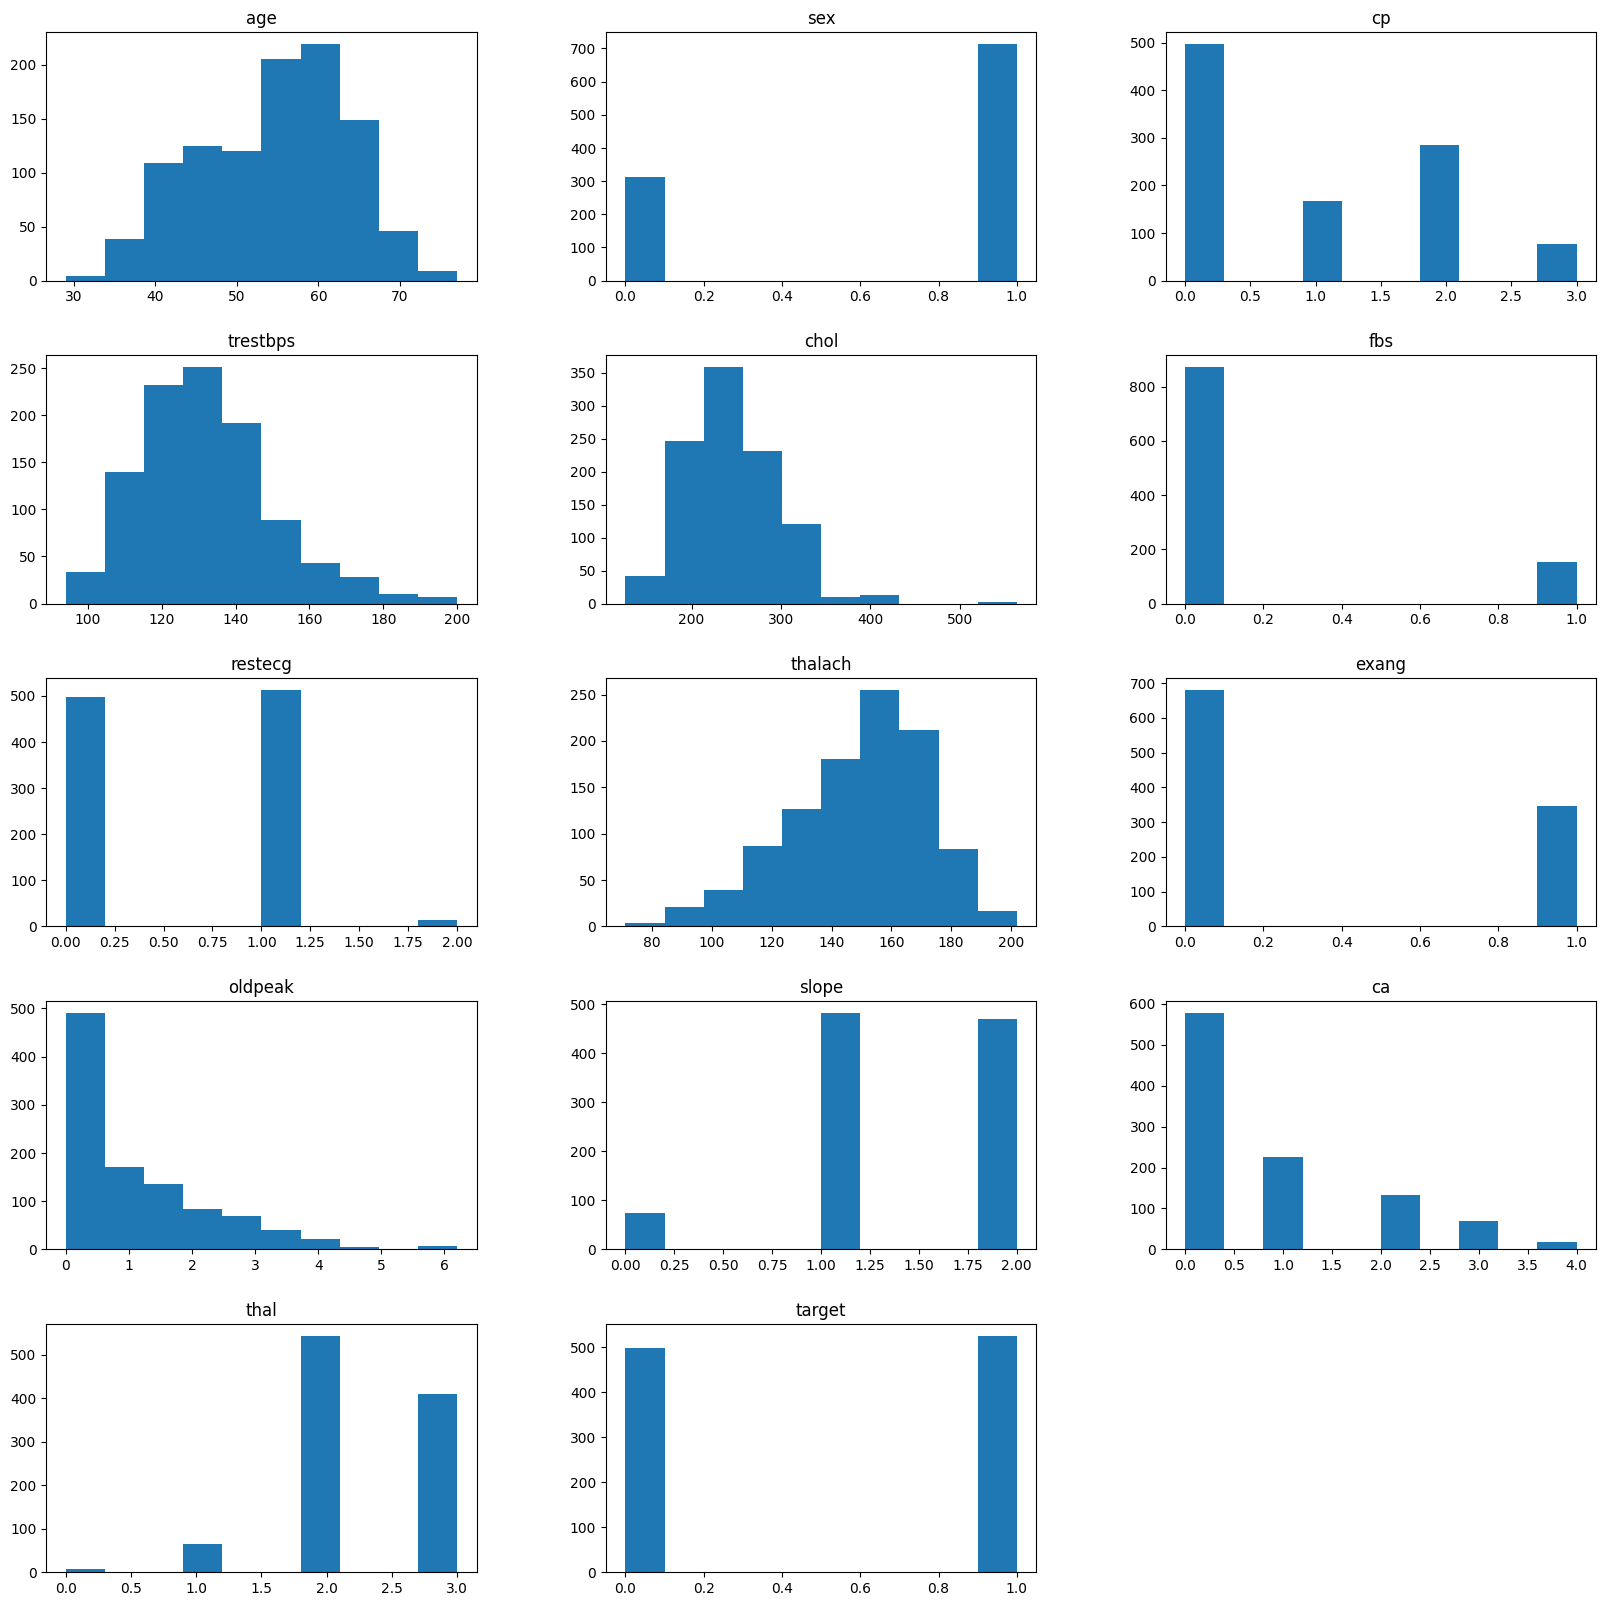

In [6]:
#histogram of Features
df.hist( 
    figsize=(20, 20),
    grid=False,
    layout=(5, 3)
)

In [7]:
num_cols = list(df.columns)
num_cols.remove('target')
num_cols

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal']

In [34]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_test,y_train = train_test_split(df[num_cols],df['target'],test_size=0.3)

In [ ]:
from sklearn.preprocessing import S

In [31]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# --- 1. DATA PREPARATION ---
# Assuming 'df' is your dataframe with 1,025 rows
X = df.drop('target', axis=1)
y = df['target']
feature_names = X.columns

# Scale data once globally (Standardization is mandatory for SVM)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. THE FITNESS FUNCTION ---
def fitness_function(position):
    """
    This is the 'food source' for the Jellyfish. 
    A higher accuracy means more food.
    """
    # Convert continuous position (0 to 1) to binary feature mask
    selected_indices = np.where(position > 0.5)[0]
    
    # Penalty if no features are selected
    if len(selected_indices) == 0:
        return 0
    
    # Select the columns
    X_subset = X_scaled[:, selected_indices]
    
    # Replicating the paper's 10-fold CV with your tuned SVC
    model = AdaBoostClassifier()
    scores = cross_val_score(model, X_subset, y, cv=10)
    
    return scores.mean()

# --- 3. JELLYFISH SEARCH OPTIMIZER ---
def jellyfish_search(n_jellyfish=20, max_iter=30):
    n_features = X.shape[1]
    
    # Initialize Population (random positions between 0 and 1)
    X_pop = np.random.rand(n_jellyfish, n_features)
    fitness = np.array([fitness_function(ind) for ind in X_pop])
    
    # Track the Global Best
    best_idx = np.argmax(fitness)
    best_pos = X_pop[best_idx].copy()
    best_fit = fitness[best_idx]
    
    print(f"Initial Best Accuracy: {best_fit:.4%}")

    for t in range(max_iter):
        # Time Control Coefficient (ct) - dictates exploration vs exploitation
        ct = np.abs((1 - t/max_iter) * (2 * np.random.rand() - 1))
        
        for i in range(n_jellyfish):
            if ct >= 0.5:
                # --- BEHAVIOR 1: Ocean Current ---
                # Jellyfish follow the trend toward the best current position
                mu = np.mean(X_pop, axis=0)
                trend = best_pos - (3 * np.random.rand() * mu)
                new_pos = X_pop[i] + np.random.rand() * trend
            else:
                # --- BEHAVIOR 2: Swarm Movement ---
                if np.random.rand() > (1 - ct):
                    # Passive Motion (Type A)
                    new_pos = X_pop[i] + 0.1 * np.random.rand() * (1 - 0)
                else:
                    # Active Motion (Type B)
                    # Pick a random jellyfish to compare food sources
                    j = np.random.randint(n_jellyfish)
                    if fitness[j] > fitness[i]:
                        new_pos = X_pop[i] + np.random.rand() * (X_pop[j] - X_pop[i])
                    else:
                        new_pos = X_pop[i] + np.random.rand() * (X_pop[i] - X_pop[j])

            # Boundary Constraints
            new_pos = np.clip(new_pos, 0, 1)
            
            # Selection (Greedy update)
            new_fit = fitness_function(new_pos)
            if new_fit > fitness[i]:
                X_pop[i] = new_pos
                fitness[i] = new_fit
                
        # Update Global Best
        if np.max(fitness) > best_fit:
            best_fit = np.max(fitness)
            best_pos = X_pop[np.argmax(fitness)].copy()
            
        print(f"Iteration {t+1}: Best Accuracy = {best_fit:.4%}")

    return best_pos, best_fit

# --- 4. EXECUTION ---
best_mask, final_accuracy = jellyfish_search(n_jellyfish=15, max_iter=20)

# Final Results
selected_features = feature_names[best_mask > 0.5].tolist()
print("\n" + "="*30)
print(f"OPTIMIZATION COMPLETE")
print(f"Best Accuracy: {final_accuracy:.4%}")
print(f"Selected Features ({len(selected_features)}): {selected_features}")
print("="*30)

Initial Best Accuracy: 85.7462%
Iteration 1: Best Accuracy = 86.7295%
Iteration 2: Best Accuracy = 86.7295%
Iteration 3: Best Accuracy = 87.0160%
Iteration 4: Best Accuracy = 87.0160%
Iteration 5: Best Accuracy = 87.0160%
Iteration 6: Best Accuracy = 87.1245%
Iteration 7: Best Accuracy = 87.1245%
Iteration 8: Best Accuracy = 87.1245%
Iteration 9: Best Accuracy = 87.1245%
Iteration 10: Best Accuracy = 87.1245%
Iteration 11: Best Accuracy = 87.1245%
Iteration 12: Best Accuracy = 87.1245%
Iteration 13: Best Accuracy = 87.1245%
Iteration 14: Best Accuracy = 87.1245%
Iteration 15: Best Accuracy = 87.1245%
Iteration 16: Best Accuracy = 87.1245%
Iteration 17: Best Accuracy = 87.1245%
Iteration 18: Best Accuracy = 87.1245%
Iteration 19: Best Accuracy = 87.1245%
Iteration 20: Best Accuracy = 87.1245%

OPTIMIZATION COMPLETE
Best Accuracy: 87.1245%
Selected Features (12): ['sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
